# Sparse Autoencoder Experiments


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [17]:
transform = transforms.ToTensor()  # tensor(0.) tensor(1.)

# transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize((0.5), (0.5))
# ])  # -> tensor(-1.) tensor(1.) for tanh activation function

mnist_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

data_loader = torch.utils.data.DataLoader(dataset=mnist_data,
                                          batch_size=64,
                                          shuffle=True)

In [18]:
dataiter = iter(data_loader)
images, labels = next(dataiter)
print(torch.min(images), torch.max(images))

tensor(0.) tensor(1.)


In [19]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Reduce the size
        # N(=batch size), 784(=28x28)
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),  # N, 784 -> N, 128
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 12),
            nn.ReLU(),
            nn.Linear(12, 3)  # -> N, 3
        )

        self.decoder = nn.Sequential(
            # N, 3 -> N, 784

            nn.Linear(3, 12),
            nn.ReLU(),
            nn.Linear(12, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid()  # Activation Funciton
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Note: [-1, 1] -> nn.Tanh

In [20]:
class Autoencoder(nn.Module):
    def __init__(self):
        
        super().__init__()
        self.encoder = nn.Sequential(
            # N, 1, 28, 28
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  # N, 16, 14, 14
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # N, 32, 7, 7
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=7) # stride=1, padding=0 # N, 64, 1, 1
        )

        self.decoder = nn.Sequential(
            # N, 64, 1, 1
            nn.ConvTranspose2d(64, 32, 7), # N, 32, 7, 7
            nn.ReLU(),           
            # IMPORTNAT! use output_padding to produce output spatial size 14, not 13
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), # N, 16, 14, 14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1), # N, 1, 28, 28
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Note: [-1, 1] -> nn.Tanh
# nn.MaxPool2d <-> nn.MaxUnpool2d

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(torch.cuda.get_device_name(0))

model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2, weight_decay=1e-5)

Using device: cuda
NVIDIA GeForce RTX 5080


In [22]:
num_epochs = 10
outputs = []

for epoch in range(num_epochs):
    for (img, _) in data_loader:
        img = img.to(device)
        # img = img.reshape(-1, 28 * 28) # for Autoencoder_Linear
        recon = model(img)
        loss = criterion(recon, img)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f'Epoch:{epoch + 1}, Loss:{loss.item():.4f}')
    outputs.append((epoch, img.detach().cpu(), recon.detach().cpu()))  # original image, reconstructed image

Epoch:1, Loss:0.0060
Epoch:2, Loss:0.0048
Epoch:3, Loss:0.0050
Epoch:4, Loss:0.0049
Epoch:5, Loss:0.0054
Epoch:6, Loss:0.0043
Epoch:7, Loss:0.0052
Epoch:8, Loss:0.0045
Epoch:9, Loss:0.0042
Epoch:10, Loss:0.0047


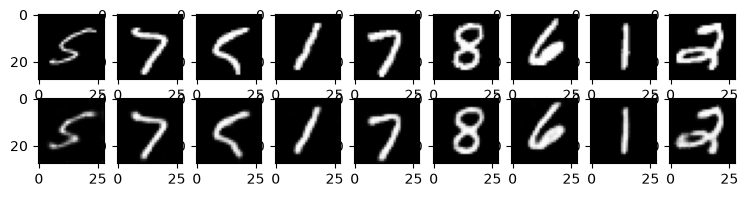

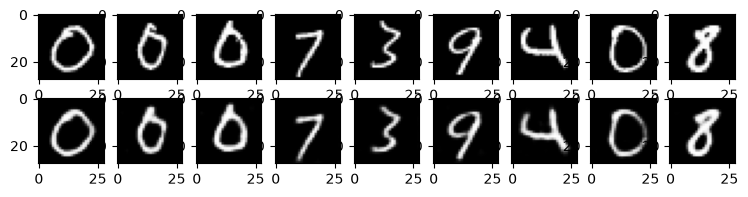

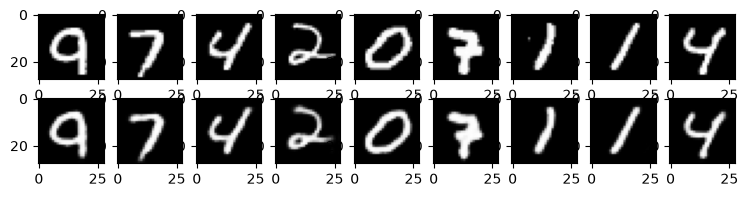

In [23]:
for k in range(0, num_epochs, 4):
    plt.figure(figsize=(9, 2))
    plt.gray()
    imgs = outputs[k][1].detach().numpy()
    recon = outputs[k][2].detach().numpy()
    for i, item in enumerate(imgs):
        if i >= 9:
            break
        plt.subplot(2, 9, i + 1)
        item = item.reshape(-1, 28, 28)
        # item: 1, 28, 28
        plt.imshow(item[0])

    for i, item in enumerate(recon):
        if i >= 9:
            break
        plt.subplot(2, 9, 9 + i + 1)  # row_length + i + 1
        item = item.reshape(-1, 28, 28)
        # item: 1, 28, 28
        plt.imshow(item[0])

## Sparse Autoencoder Experiments

Train the same convolutional autoencoder with different sparse priors by changing `omega(h)`. Each block trains a fresh model and shows decoder reconstruction results.


### i. Gaussian prior

`omega(h) = 0.5 * h^2`


In [24]:
gaussian_model = Autoencoder().to(device)
gaussian_optimizer = torch.optim.Adam(gaussian_model.parameters(), lr=1e-2, weight_decay=1e-5)
gaussian_lambda = 1e-1
gaussian_outputs = []

for epoch in range(num_epochs):
    for (img, _) in data_loader:
        img = img.to(device)
        h = gaussian_model.encoder(img)
        recon = gaussian_model.decoder(h)

        recon_loss = criterion(recon, img)
        sparse_loss = 0.5 * torch.mean(h ** 2)
        loss = recon_loss + gaussian_lambda * sparse_loss

        gaussian_optimizer.zero_grad()
        loss.backward()
        gaussian_optimizer.step()

    print(
        f'Epoch:{epoch + 1}, '
        f'Loss:{loss.item():.4f}, '
        f'Recon:{recon_loss.item():.4f}, '
        f'Sparse:{sparse_loss.item():.4f}'
    )
    gaussian_outputs.append((epoch, img.detach().cpu(), recon.detach().cpu()))

Epoch:1, Loss:0.0092, Recon:0.0084, Sparse:0.0072
Epoch:2, Loss:0.0083, Recon:0.0077, Sparse:0.0062
Epoch:3, Loss:0.0068, Recon:0.0062, Sparse:0.0059
Epoch:4, Loss:0.0066, Recon:0.0060, Sparse:0.0059
Epoch:5, Loss:0.0062, Recon:0.0056, Sparse:0.0061
Epoch:6, Loss:0.0064, Recon:0.0058, Sparse:0.0059
Epoch:7, Loss:0.0054, Recon:0.0049, Sparse:0.0053
Epoch:8, Loss:0.0069, Recon:0.0063, Sparse:0.0062
Epoch:9, Loss:0.0063, Recon:0.0057, Sparse:0.0058
Epoch:10, Loss:0.0064, Recon:0.0058, Sparse:0.0059


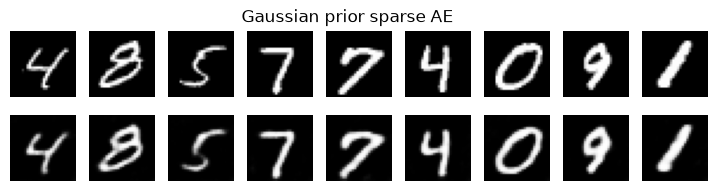

In [25]:
k = num_epochs - 1
plt.figure(figsize=(9, 2))
plt.gray()
imgs = gaussian_outputs[k][1].numpy()
recon = gaussian_outputs[k][2].numpy()

for i, item in enumerate(imgs[:9]):
    plt.subplot(2, 9, i + 1)
    plt.imshow(item.reshape(28, 28))
    plt.axis('off')

for i, item in enumerate(recon[:9]):
    plt.subplot(2, 9, 9 + i + 1)
    plt.imshow(item.reshape(28, 28))
    plt.axis('off')

plt.suptitle('Gaussian prior sparse AE')
plt.show()

### ii. Laplace prior

`omega(h) = |h|`


In [26]:
laplace_model = Autoencoder().to(device)
laplace_optimizer = torch.optim.Adam(laplace_model.parameters(), lr=1e-2, weight_decay=1e-5)
laplace_lambda = 1e-3
laplace_outputs = []

for epoch in range(num_epochs):
    for (img, _) in data_loader:
        img = img.to(device)
        h = laplace_model.encoder(img)
        recon = laplace_model.decoder(h)

        recon_loss = criterion(recon, img)
        sparse_loss = torch.mean(torch.abs(h))
        loss = recon_loss + laplace_lambda * sparse_loss

        laplace_optimizer.zero_grad()
        loss.backward()
        laplace_optimizer.step()

    print(
        f'Epoch:{epoch + 1}, '
        f'Loss:{loss.item():.4f}, '
        f'Recon:{recon_loss.item():.4f}, '
        f'Sparse:{sparse_loss.item():.4f}'
    )
    laplace_outputs.append((epoch, img.detach().cpu(), recon.detach().cpu()))

Epoch:1, Loss:0.0064, Recon:0.0059, Sparse:0.4498
Epoch:2, Loss:0.0048, Recon:0.0044, Sparse:0.3784
Epoch:3, Loss:0.0040, Recon:0.0037, Sparse:0.3667
Epoch:4, Loss:0.0048, Recon:0.0045, Sparse:0.3795
Epoch:5, Loss:0.0055, Recon:0.0052, Sparse:0.3880
Epoch:6, Loss:0.0046, Recon:0.0042, Sparse:0.3766
Epoch:7, Loss:0.0045, Recon:0.0041, Sparse:0.3885
Epoch:8, Loss:0.0047, Recon:0.0043, Sparse:0.3697
Epoch:9, Loss:0.0041, Recon:0.0037, Sparse:0.3814
Epoch:10, Loss:0.0046, Recon:0.0042, Sparse:0.3669


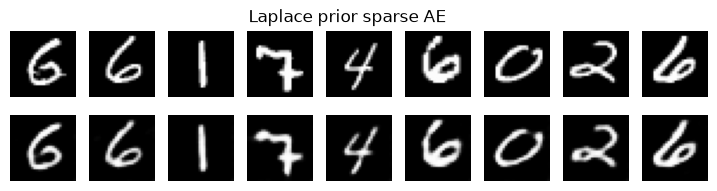

In [27]:
k = num_epochs - 1
plt.figure(figsize=(9, 2))
plt.gray()
imgs = laplace_outputs[k][1].numpy()
recon = laplace_outputs[k][2].numpy()

for i, item in enumerate(imgs[:9]):
    plt.subplot(2, 9, i + 1)
    plt.imshow(item.reshape(28, 28))
    plt.axis('off')

for i, item in enumerate(recon[:9]):
    plt.subplot(2, 9, 9 + i + 1)
    plt.imshow(item.reshape(28, 28))
    plt.axis('off')

plt.suptitle('Laplace prior sparse AE')
plt.show()

### iii. Student-t prior

`omega(h) = log(1 + h^2 / nu)`


In [28]:
student_t_model = Autoencoder().to(device)
student_t_optimizer = torch.optim.Adam(student_t_model.parameters(), lr=1e-2, weight_decay=1e-5)
student_t_lambda = 1e-1
student_t_nu = 3.0
student_t_outputs = []

for epoch in range(num_epochs):
    for (img, _) in data_loader:
        img = img.to(device)
        h = student_t_model.encoder(img)
        recon = student_t_model.decoder(h)

        recon_loss = criterion(recon, img)
        sparse_loss = torch.mean(torch.log1p((h ** 2) / student_t_nu))
        loss = recon_loss + student_t_lambda * sparse_loss

        student_t_optimizer.zero_grad()
        loss.backward()
        student_t_optimizer.step()

    print(
        f'Epoch:{epoch + 1}, '
        f'Loss:{loss.item():.4f}, '
        f'Recon:{recon_loss.item():.4f}, '
        f'Sparse:{sparse_loss.item():.4f}'
    )
    student_t_outputs.append((epoch, img.detach().cpu(), recon.detach().cpu()))

Epoch:1, Loss:0.0120, Recon:0.0113, Sparse:0.0070
Epoch:2, Loss:0.0102, Recon:0.0097, Sparse:0.0055
Epoch:3, Loss:0.0079, Recon:0.0074, Sparse:0.0055
Epoch:4, Loss:0.0085, Recon:0.0080, Sparse:0.0058
Epoch:5, Loss:0.0072, Recon:0.0067, Sparse:0.0054
Epoch:6, Loss:0.0063, Recon:0.0058, Sparse:0.0055
Epoch:7, Loss:0.0062, Recon:0.0056, Sparse:0.0053
Epoch:8, Loss:0.0072, Recon:0.0066, Sparse:0.0054
Epoch:9, Loss:0.0060, Recon:0.0054, Sparse:0.0054
Epoch:10, Loss:0.0056, Recon:0.0050, Sparse:0.0060


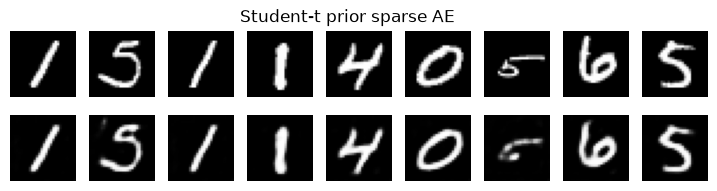

In [29]:
k = num_epochs - 1
plt.figure(figsize=(9, 2))
plt.gray()
imgs = student_t_outputs[k][1].numpy()
recon = student_t_outputs[k][2].numpy()

for i, item in enumerate(imgs[:9]):
    plt.subplot(2, 9, i + 1)
    plt.imshow(item.reshape(28, 28))
    plt.axis('off')

for i, item in enumerate(recon[:9]):
    plt.subplot(2, 9, 9 + i + 1)
    plt.imshow(item.reshape(28, 28))
    plt.axis('off')

plt.suptitle('Student-t prior sparse AE')
plt.show()

## Decode Result Comparison

Compare baseline and sparse AE decoder outputs on the same mini-batch.


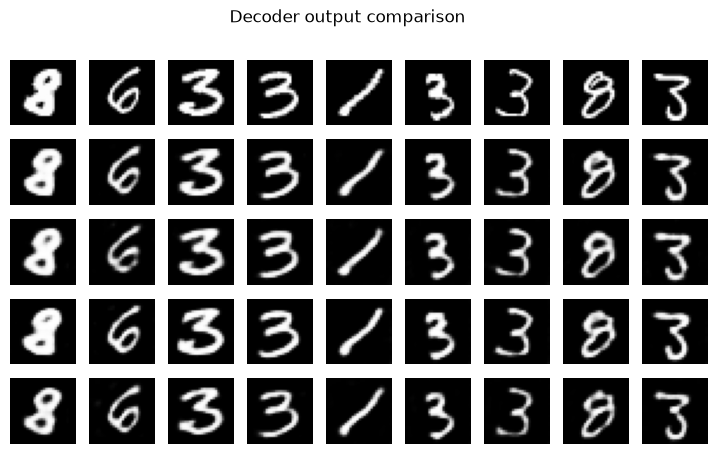

In [30]:
compare_imgs, _ = next(iter(data_loader))
compare_imgs = compare_imgs.to(device)

model.eval()
gaussian_model.eval()
laplace_model.eval()
student_t_model.eval()

with torch.no_grad():
    baseline_recon = model(compare_imgs[:9]).cpu()
    gaussian_recon = gaussian_model(compare_imgs[:9]).cpu()
    laplace_recon = laplace_model(compare_imgs[:9]).cpu()
    student_t_recon = student_t_model(compare_imgs[:9]).cpu()

rows = [
    ('original', compare_imgs[:9].cpu()),
    ('baseline', baseline_recon),
    ('gaussian', gaussian_recon),
    ('laplace', laplace_recon),
    ('student-t', student_t_recon),
]

plt.figure(figsize=(9, 5))
plt.gray()
for row_idx, (name, row_imgs) in enumerate(rows):
    for col_idx, item in enumerate(row_imgs):
        ax = plt.subplot(len(rows), 9, row_idx * 9 + col_idx + 1)
        ax.imshow(item.squeeze().numpy())
        ax.axis('off')
        if col_idx == 0:
            ax.set_ylabel(name, rotation=0, labelpad=28, va='center')

plt.suptitle('Decoder output comparison')
plt.show()